In [1]:
import os
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [2]:
if torch.backends.mps.is_available():
    device = "mps" 
else:
    device = "cpu" 
print(f"Используемое вычислительное устройство: {device}")

Используемое вычислительное устройство: mps


In [3]:
checkpoint_path = "../data/sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

In [4]:
sam2_model = build_sam2(model_cfg, checkpoint_path, device=device)
predictor = SAM2ImagePredictor(sam2_model)

In [5]:
def segment_and_save_with_debug(image_path, clicks_coords, clicks_labels, output_dir="../data/output/"):
    image = cv2.imread(image_path)
    if image is None: return
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image_rgb)

    input_points = np.array(clicks_coords)
    input_labels = np.array(clicks_labels)

    masks, _, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=False
    )
    best_mask = masks[0].squeeze().astype(bool)

    black_background = np.zeros_like(image_rgb)
    black_background[best_mask] = image_rgb[best_mask]


    fig, axes = plt.subplots(1, 2, figsize=(19, 11), dpi=300)

    
    axes[0].imshow(image_rgb)
    
    pos_points = input_points[input_labels == 1]
    neg_points = input_points[input_labels == 0]

    if len(pos_points) > 0:
        axes[0].scatter(pos_points[:, 0], pos_points[:, 1], color='lime', marker='*', s=200, label='Позитив (+)', edgecolor='white')
    
    if len(neg_points) > 0:
        axes[0].scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=200, label='Негатив (-)', edgecolor='white')

    axes[0].set_title("Исходный кадр с точками (SAM 2)")
    if len(pos_points) > 0 or len(neg_points) > 0:
        axes[0].legend()
    axes[0].axis('on') 

    axes[1].imshow(black_background)
    axes[1].set_title("Результат вырезания")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show() 

   
    original_name = Path(image_path).stem 
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    os.makedirs(output_dir, exist_ok=True)

    full_filename = f"{original_name}_full_{timestamp}.jpg"
    cv2.imwrite(os.path.join(output_dir, full_filename), cv2.cvtColor(black_background, cv2.COLOR_RGB2BGR))

    y_indices, x_indices = np.where(best_mask)
    if len(x_indices) > 0 and len(y_indices) > 0:
        padding = 10
        x_min, x_max = max(0, x_indices.min() - padding), min(image_rgb.shape[1], x_indices.max() + padding)
        y_min, y_max = max(0, y_indices.min() - padding), min(image_rgb.shape[0], y_indices.max() + padding)
        cropped_fish = black_background[y_min:y_max, x_min:x_max]
        cv2.imwrite(os.path.join(output_dir, f"{original_name}_crop_{timestamp}.jpg"), cv2.cvtColor(cropped_fish, cv2.COLOR_RGB2BGR))
        print(f"Обработано и визуализировано: {original_name}")

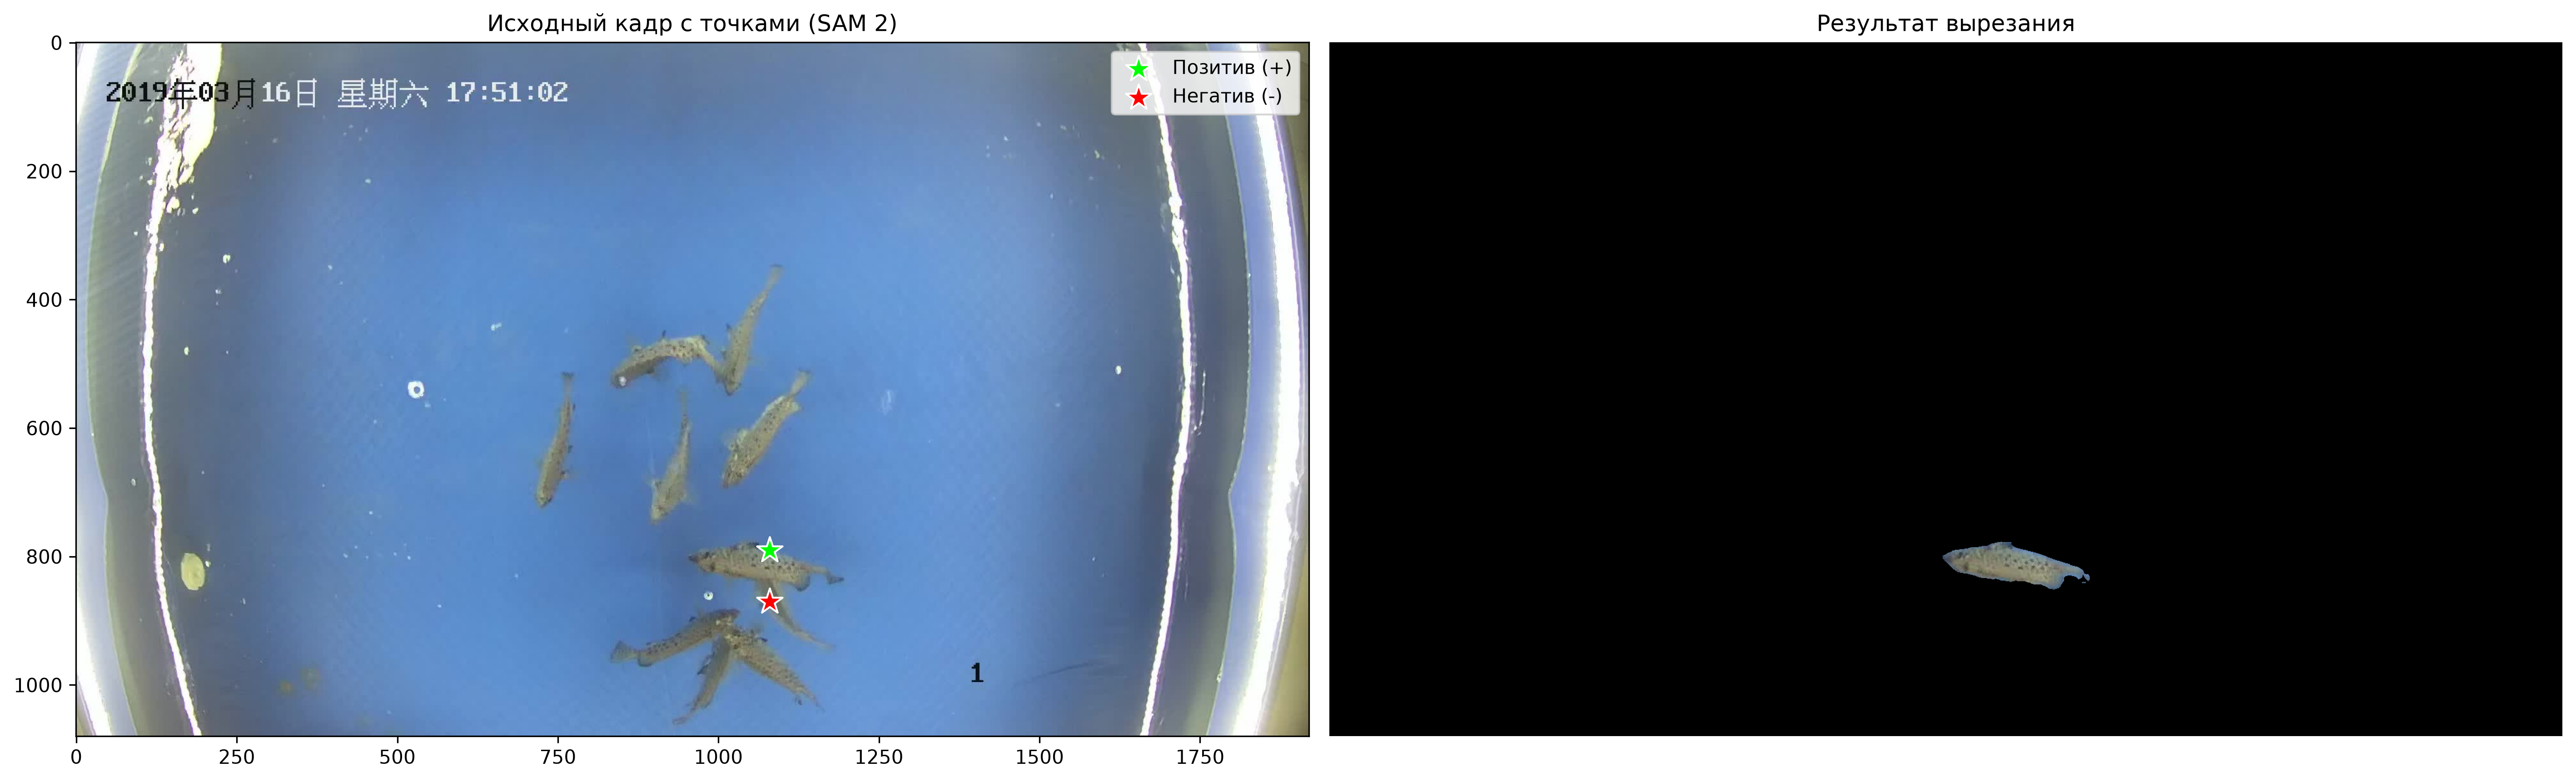

Обработано и визуализировано: 000001


In [6]:
segment_and_save_with_debug(
    image_path="../data/MFT25-train/BT-001/img1/000001.jpg",
    clicks_coords=[[1080, 790], [1080, 870]], 
    clicks_labels=[1, 0] 
)